In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# 1. Add project root to path
# This allows us to import from 'src' even though we are in 'notebooks'
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# 2. Import project modules
from src.data.partition import partition_data

print(f"✅ Project Root set to: {PROJECT_ROOT}")

✅ Project Root set to: /scratch1/e20-fyp-backdoor-resilience/ishara/e20-4yp-backdoor-resilient-federated-nids


In [2]:
def visualize_partition(dataset, partitions, num_classes=10, title="Data Distribution"):
    """
    Plots a stacked bar chart showing how classes are distributed across clients.
    If binarize_nonzero=True, all nonzero counts are set to 1 (0 stays 0).
    """

    labels = dataset.tensors[1].numpy() # TensorDataset

    # 2. Setup Data Matrix (Rows=Clients, Cols=Classes)
    n_clients = len(partitions)
    client_ids = range(n_clients)
    class_counts = np.zeros((n_clients, num_classes))

    # 3. Fill Matrix
    for cid, indices in partitions.items():
        if len(indices) == 0: continue
        client_labels = labels[indices]
        counts = Counter(client_labels)
        for cls, count in counts.items():
            class_counts[cid, cls] = count

    # 4. Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    bottom = np.zeros(n_clients)
    
    # Use a distinct colormap
    colors = plt.get_cmap('tab10')

    for cls in range(num_classes):
        ax.bar(client_ids, class_counts[:, cls], bottom=bottom, 
               label=f'Class {cls}', color=colors(cls), alpha=0.9)
        bottom += class_counts[:, cls]

    # 5. Formatting
    ax.set_xlabel('Client ID', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(client_ids)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Legend outside the plot
    ax.legend(title="Attack Class", bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

📂 Loading data from: /scratch1/e20-fyp-backdoor-resilience/ishara/e20-4yp-backdoor-resilient-federated-nids/data/unsw-nb15/processed/train_pool.pt
Generating IID Partition (Binary Labels)...
🔪 Partitioning 206138 samples for 10 clients (Method: iid)...


/tmp/ipykernel_4132513/1917527626.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_payload = torch.load(data_path)


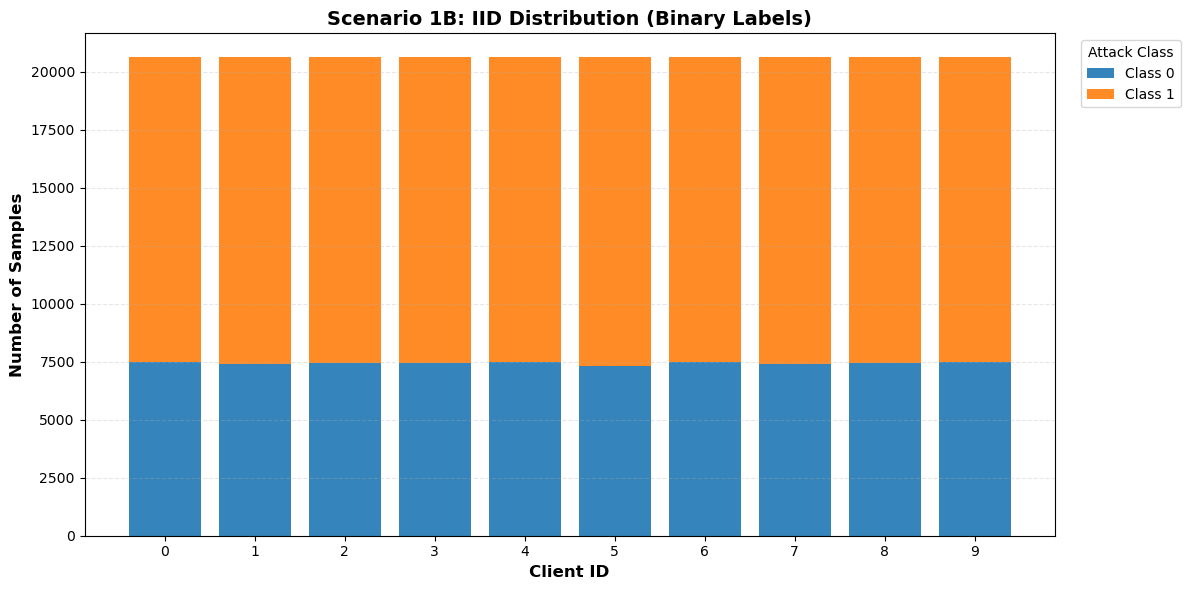

In [3]:
# Path to your processed data
data_path = os.path.join(PROJECT_ROOT, "data/unsw-nb15/processed/train_pool.pt")

# Load the dictionary payload
print(f"📂 Loading data from: {data_path}")
data_payload = torch.load(data_path)

from torch.utils.data import TensorDataset

# Create binary labels: 0 stays 0, all others become 1
binary_y = (data_payload['y'] != 0).long()
binary_train_pool = TensorDataset(data_payload['X'], binary_y)

print("Generating IID Partition (Binary Labels)...")
partitions_iid_bin = partition_data(binary_train_pool, n_clients=10, method="iid")

visualize_partition(binary_train_pool, partitions_iid_bin, num_classes=2, title="Scenario 1B: IID Distribution (Binary Labels)")

Generating Non-IID Partition (Dirichlet)...
🔪 Partitioning 206138 samples for 10 clients (Method: dirichlet)...


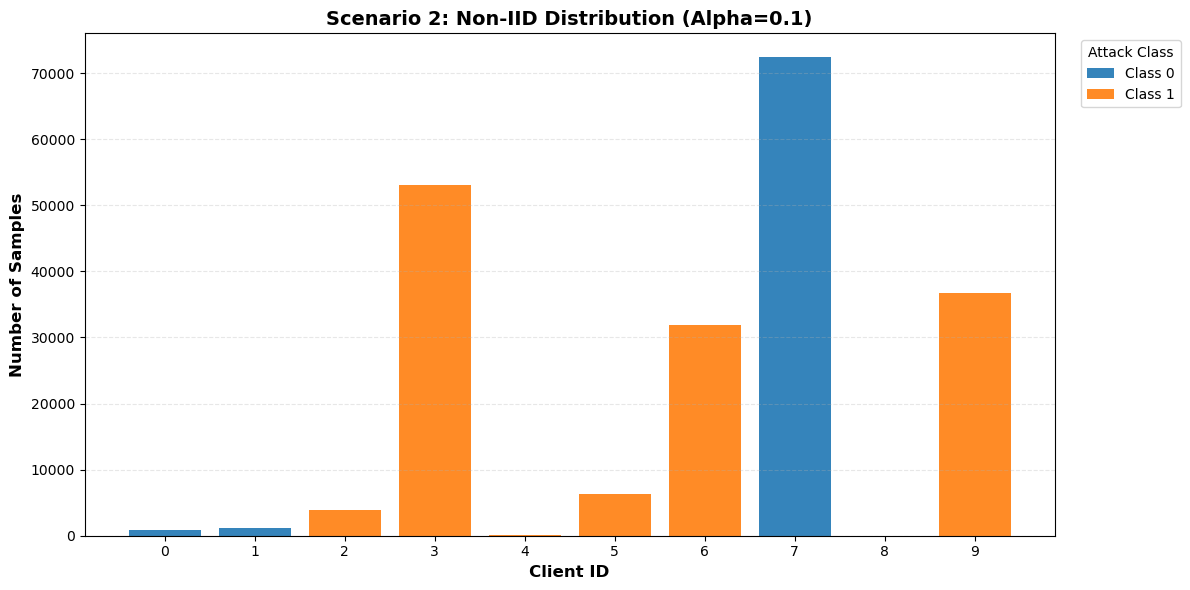

In [4]:
# --- SCENARIO 2: Non-IID (Alpha = 0.1) ---
print("Generating Non-IID Partition (Dirichlet)...")
partitions_skew = partition_data(binary_train_pool, n_clients=10, method="dirichlet", alpha=0.1)

visualize_partition(binary_train_pool, partitions_skew,num_classes=2, title="Scenario 2: Non-IID Distribution (Alpha=0.1)")

Generating Pathological Partition (2 Shards/Client)...
🔪 Partitioning 206138 samples for 10 clients (Method: pathological)...


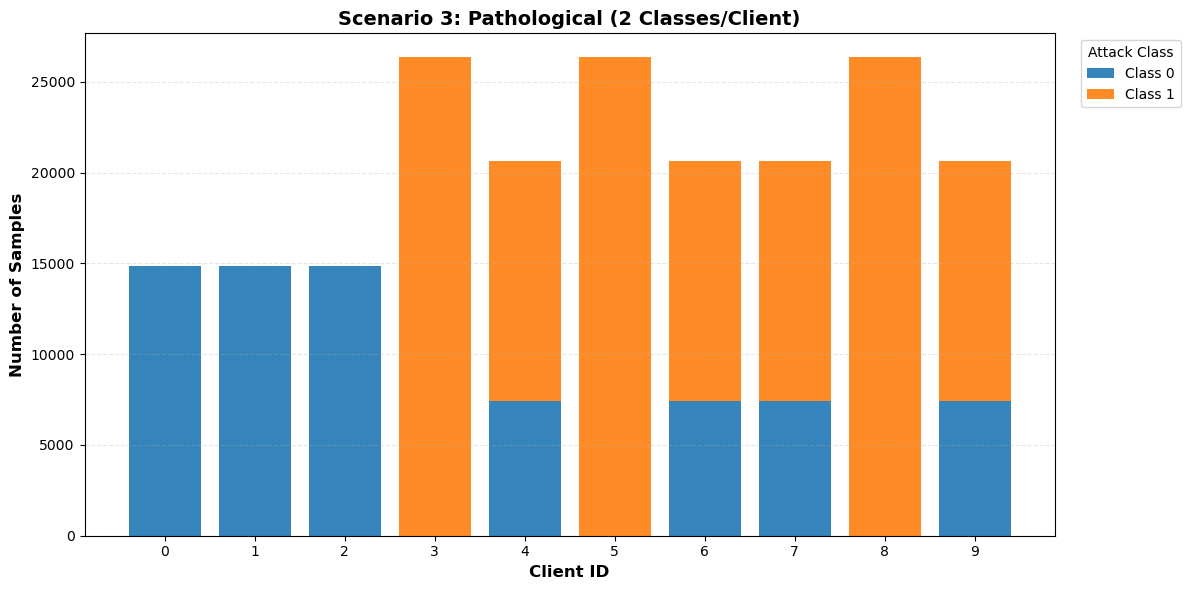

In [6]:
# --- SCENARIO 3: Pathological (Exact 2 Classes per Client) ---
print("Generating Pathological Partition (2 Shards/Client)...")

partitions_path = partition_data(binary_train_pool, n_clients=10, method="pathological")

visualize_partition(binary_train_pool, partitions_path, num_classes=2, title="Scenario 3: Pathological (2 Classes/Client)")